# Demo: Training as a Service (Training-aaS)


`Training-aaS` is the concept of training models on the Hafnia platform using large
and _hidden_ datasets. Hidden datasets refer to datasets that can be used for
training, but are not available for download or direct access.

This is a key feature of the Hafnia platform, as hidden datasets ensure data
privacy and allow models to be trained compliantly and ethically by third parties (you).

## Getting started

1. Access the platform and register to create a user:
   - Production: https://hafnia.milestonesys.com/
   - Staging: https://staging.projecthafnia.com
2. Get get access to Training-aaS you may either:
   a) Ask Ahmed to be invited to our TaaS-Ready Organization on the platform.
   b) Enable Training-aaS for your user with below trick:
   - Production: https://hafnia.milestonesys.com/dashboard/training-aas?enable=true
   - Staging: https://staging.projecthafnia.com/dashboard/training-aas?enable=true


## Training-aaS using the Platform Portal only

1. Click "Dashboard".
2. Click "Training-aaS". If the feature is locked, check getting started step 3.
3. Click "New Experiment" in the top right corner to start model training.
4. Select "Dataset".
   - To train a Classification model, select a classification dataset such as MNIST or "Caltech256".
   - To train an Object Detection model, select an object detection dataset such as "COCO 2017" or "Midwest Vehicle Detection".
5. Fill in the trainer form:
   - **Select the "Public Trainer" tab**.
     Two trainers are available:
     - **Image Classification Trainer**: Use this trainer for training an Image Classification model. This trainer only works with IC datasets.
     - **Object Detection Trainer**: Use this trainer for training an Object Detection model. This trainer only works with OD datasets.
   - **Insert command**:
     - Use the default: `python scripts/train.py`. A description is not needed.
   - **Select hardware**: Use the "Free Tier".
6. Click "Next".

### Using a Dataset Recipe with Training-aaS

Training a model using a dataset recipe is very similar to the above.
The only difference is that you will need to select the "Data Recipes" tab in Step 4.


# Getting started: Running this notebook

To get this notebook running you will need to do the following:

Clone repo:

1. Clone the repository
2. Install uv (linux and macOS) to managing python dependencies

   ```bash
   curl -LsSf https://astral.sh/uv/install.sh | sh
   ```

3. Create virtual environment and install python dependencies

   ```bash
   uv sync --dev
   ```

4. In vs code, you should open the notebook and select the project virtual environment installed by uv
   in [PROJECT_ROOT]/.venv/bin/python


## Hafnia SDK: Getting Access to the Hafnia Platform

1. Create an API key for Training-aaS:
   - Go to the platform dashboard:
     - Production: https://hafnia.milestonesys.com/dashboard
     - Staging: https://staging.projecthafnia.com/dashboard
   - Select "API keys".
   - Create and copy your API key for later.

2. From the terminal, configure your machine to access Hafnia using a single command:

```bash
# Staging
API_KEY_STAGING="[INSERT_API_KEY_HERE]"
hafnia profile create "${API_KEY_STAGING}" --name staging --api-url https://api.staging.projecthafnia.com
hafnia profile use staging

# Production
API_KEY_PROD=[INSERT_API_KEY_HERE]
hafnia profile create "${API_KEY_PROD}" --name production
hafnia profile use production
```

3. Download `mnist` from the terminal to verify that your configuration is working:

   ```bash
   hafnia dataset download mnist --force
   ```


## Hafnia Dataset Format

We have developed our own dataset format.
Key characteristics of a Hafnia dataset:

- The dataset is standardized, meaning that all datasets are formatted in the same way.
- Binary data (images, videos) are stored in their original format.
- Metadata is stored in a DataFrame using Polars, enabling very fast and expressive operations on metadata.
- Projects and tasks are stored separately.

For more information on the Hafnia dataset format, check out https://github.com/milestone-hafnia/hafnia/blob/main/examples/example_hafnia_dataset.py


In [1]:
from hafnia.dataset.hafnia_dataset import HafniaDataset

# Get 'caltech101' sample dataset
custom_dataset = HafniaDataset.from_name_public_dataset("caltech-101")
custom_dataset.print_basic_stats()

Output()

                          Dataset Statistics                          
                                                                      
  Property                                    Value                   
 ──────────────────────────────────────────────────────────────────── 
  Dataset Name                                caltech-101             
                                                                      
  Version                                     1.0.0                   
                                                                      
  Number of samples                           9144                    
                                                                      
  Task: Classification:image_classification   Number of classes: 102

# Training on Custom Data

To train a model on custom data, you will need to:

1. Have your custom dataset in a Hafnia dataset format:
   - Use case 1: Your dataset is already in a Hafnia format. Load the dataset with `HafniaDataset.from_path(PATH_DATASET)`.
   - Use case 2: Your dataset is in a supported format and can be imported directly. `HafniaDataset.from_yolo_format()`, `HafniaDataset.from_coco_format()`, and `HafniaDataset.from_image_classification_folder`, etc.
   - Use case 3: Your dataset is stored in a custom or unsupported format. Create a custom script to convert it to a Hafnia dataset. Check out the example at https://github.com/milestone-hafnia/hafnia/blob/main/examples/example_custom_dataset.py
2. Upload the Hafnia dataset to our platform.
3. Launch a training run through the portal by selecting the newly created dataset.


## Step 1: Create a Hafnia Dataset from a Custom Dataset

A simple example where a Hafnia dataset is created from a supported YOLO format.


In [2]:
from pathlib import Path
import uuid

unique_dataset_name = f"custom-dataset-{str(uuid.uuid4())[:8]}"
path_yolo = Path("../tests/data/dataset_formats/format_yolo")
custom_dataset = HafniaDataset.from_yolo_format(path_yolo)
custom_dataset.info.dataset_name = unique_dataset_name
custom_dataset.print_basic_stats()

Output()

Output()

                   Dataset Statistics                    
                                                         
  Property                      Value                    
 ─────────────────────────────────────────────────────── 
  Dataset Name                  custom-dataset-55ed22d8  
                                                         
  Version                       0.0.0                    
                                                         
  Number of samples             3                        
                                                         
  Task: Bbox:object_detection   Number of classes: 80

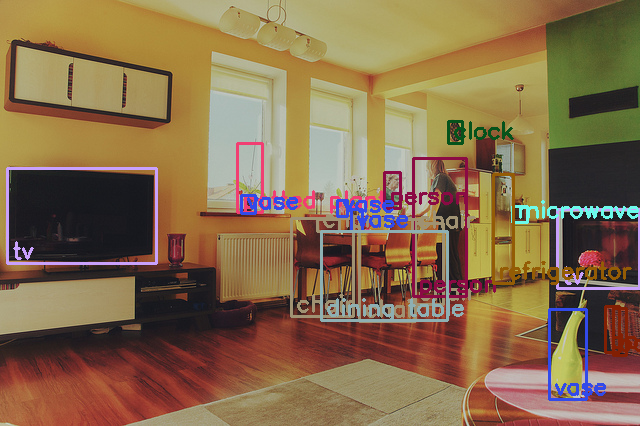

In [3]:
# Verify that the dataset is in the correct format by visualizing a sample

from hafnia.dataset.hafnia_dataset_types import Sample
from PIL import Image

sample = Sample(**custom_dataset[0])
image = sample.draw_annotations()

# Use PIL to visualize the image
image_pillow = Image.fromarray(image)
image_pillow  # This will display the image with annotations in the notebook


## Step 2: Upload Dataset to Platform

To upload the dataset, simply run the following function:


In [4]:
from hafnia.dataset.dataset_names import SampleField


gallery_image_names = [custom_dataset.samples[SampleField.FILE_PATH].str.split("/").list.last().sort()[0]]

# Upload dataset to Hafnia platform
response = custom_dataset.upload_to_platform(
    interactive=False,
    allow_version_overwrite=True,
    gallery_images=gallery_image_names,
)

Output()

[09:49:11] Syncing dataset to S3 bucket 's3://dataset-writeable-267c5397-afe4-4908-88fe-b393957a4a37/sample'

           Writing dataset annotations to /tmp/tmp5v6zgp3q...

           Sync dataset to s3://dataset-writeable-267c5397-afe4-4908-88fe-b393957a4a37/sample

           - Found that 0 / 0 data files already exist. Meaning 0 data files will be uploaded.                     
           - Will upload 3 metadata files.                                                                         
           - Total files to upload: 3

...

           Sync dataset to s3://dataset-writeable-267c5397-afe4-4908-88fe-b393957a4a37/hidden

           - Found that 0 / 3 data files already exist. Meaning 3 data files will be uploaded.                     
           - Will upload 3 metadata files.                                                                         
           - Total files to upload: 6

Output()

[09:49:12] - Synced dataset in 0.90 seconds.

[09:49:13] Exporting dataset details to platform. This may take up to 30 seconds...

## Step 3: Launch Training

You will now be able to launch a new training run using your dataset.

_Note: You will need a larger dataset than the one provided above for meaningful training._

To do so, you have two options:

1. Launch the training using the web portal as described earlier in this guide.

2. Launch an experiment directly using the Hafnia CLI:

```bash
DATASET_NAME=[INSERT_DATASET_NAME]
TRAINER_ID=[INSERT_TRAINER_ID]
hafnia experiment create --name "Training on Custom Dataset" --trainer-id $TRAINER_ID --dataset $DATASET_NAME
```

To find available trainers or datasets, check the portal or use the CLI:

```bash
# Get available trainers with the CLI tool. Use '--help' for different options. Use '-v PUBLIC' to get public trainers
hafnia trainer ls
hafnia trainer ls -v PUBLIC

# Get available datasets with the CLI tool. Use '--help' for different options
hafnia dataset ls
```


## Dataset Recipes

For some use cases it is desirable to perform dataset transformations and/or combine multiple datasets
to train your model on more data or for a specific use case.

For TaaS, we have introduced a concept called dataset recipes to achieve exactly this.
A Dataset Recipe is a declarative description of the dataset you want.
As the name implies, it is not a dataset itself, but a description of how multiple datasets and dataset
operations are combined into a specific dataset.

Only after the dataset recipe has been built (or "cooked") will it result in an actual dataset.
Unlike a real dataset, a dataset recipe can easily be stored, shared, reproduced, and reused in
different environments without moving any actual data.

We will demonstrate the flow and how a dataset recipe is created with Python code.


### Dataset Recipe: Create a Person and Vehicle Dataset from Multiple Datasets

This example demonstrates how two datasets are combined into a single dataset with two
class names: `Vehicle` and `Person`.
The challenge of combining `coco-2017` and `midwest-vehicle-detection` is that they
are labeled with different sets of class names.

The first step is to create two individual recipes — one for each dataset —
that load the desired dataset and map class names to the target classes.


In [5]:
from hafnia.dataset.dataset_recipe.dataset_recipe import DatasetRecipe


class_mapping_midwest = {
    "Person": "Person",
    "Vehicle.*": "Vehicle",
    "Vehicle.Trailer": "__REMOVE__",
}

recipe_midwest = DatasetRecipe.from_name(name="midwest-vehicle-detection", version="1.0.0").class_mapper(
    class_mapping=class_mapping_midwest, task_name="object_detection"
)


class_mapping_coco = {
    "person": "Person",
    "bicycle": "Vehicle",
    "car": "Vehicle",
    "motorcycle": "Vehicle",
    "bus": "Vehicle",
    "train": "Vehicle",
    "truck": "Vehicle",
}

recipe_coco = DatasetRecipe.from_name(name="coco-2017", version="1.0.0").class_mapper(
    class_mapping=class_mapping_coco, method="remove_undefined", task_name="object_detection"
)

After class remapping, we will now merge `recipe_midwest` and `recipe_coco` into a single recipe
and remove any image samples that do not contain the specified classes.


In [6]:
# Merge datasets using recipes and select only samples with 'Person' and 'Vehicle' classes
merged_dataset_recipe = DatasetRecipe.from_merge(
    recipe0=recipe_midwest,
    recipe1=recipe_coco,
).select_samples_by_class_name(name=["Person", "Vehicle"], task_name="object_detection")


Before proceeding further, we can build the recipe locally on a sample dataset
to verify that the recipe is valid and can be built into a dataset.


In [7]:
HafniaDataset.from_name("midwest-vehicle-detection", version="1.0.0").print_basic_stats()

[09:49:15] Dataset found locally. Set 'force=True' or add `--force` flag with cli to re-download

           Reading dataset annotations from Parquet file:                                                          
           /home/petemachine/code/hafnia/notebooks/.data/datasets/midwest-vehicle-detection/annotations.parquet

Output()

                           Dataset Statistics                            
                                                                         
  Property                                    Value                      
 ─────────────────────────────────────────────────────────────────────── 
  Dataset Name                                midwest-vehicle-detection  
                                                                         
  Version                                     1.0.0                      
                                                                         
  Number of samples                           214                        
                                                                         
  Task: Bbox:object_detection                 Number of classes: 13      
                                                                         
  Task: Classification:Weather                Number of classes: 2       
                                                                         
  Task: Classification:Surface Conditions     Number of classes: 2       
                                                                         
  Task: Classification:Geographical Context   Number of classes: 5       
                                                                         
  Task: Classification:Time of Day            Number of classes: 8       
                                                                         
  Task: Classification:Camera Motion          Number of classes: 1       
                                                                         
  Task: Classification:Location Continent     Number of classes: 1

In [8]:
dataset = merged_dataset_recipe.build()
dataset.print_stats()

           Dataset found locally. Set 'force=True' or add `--force` flag with cli to re-download

           Reading dataset annotations from Parquet file:                                                          
           /home/petemachine/code/hafnia/notebooks/.data/datasets/midwest-vehicle-detection/annotations.parquet

Output()

           Dataset found locally. Set 'force=True' or add `--force` flag with cli to re-download

           Reading dataset annotations from Parquet file:                                                          
           /home/petemachine/code/hafnia/notebooks/.data/datasets/coco-2017/annotations.parquet

...

           Task 'Location Continent' with primitive 'Classification' has been removed during the merge. This       
           happens if the two datasets do not have the same primitives.

           Task 'Camera Motion' with primitive 'Classification' has been removed during the merge. This happens if 
           the two datasets do not have the same primitives.

                         Dataset Statistics                          
                                                                     
  Property                      Value                                
 ─────────────────────────────────────────────────────────────────── 
  Dataset Name                  midwest-vehicle-detection+coco-2017  
                                                                     
  Version                       0.0.0                                
                                                                     
  Number of samples             330                                  
                                                                     
  Task: Bbox:object_detection   Number of classes: 2

       Dataset Statistics       
                                
  Split        Samples    Bbox  
 ────────────────────────────── 
  All          330        2507  
                                
  Train        286        2011  
                                
  Validation   20         243   
                                
  Test         24         253  

         Class Count for          
     'Bbox/object_detection'      
┏━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━┓
┃ Class Name ┃ Class Idx ┃ Count ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━┩
│ Person     │ 0         │   612 │
│ Vehicle    │ 1         │  1895 │
└────────────┴───────────┴───────┘

You have now verified that the dataset recipe can be built — at least on the sample dataset —
and you are ready to use it for training.

To do this, you will need to upload it to the platform:


In [9]:
response = merged_dataset_recipe.as_platform_recipe(recipe_name="merged-person-vehicle-detection", overwrite=True)
dataset_recipe_id = response["id"]
print(f"Created recipe with ID: {dataset_recipe_id}")


Created recipe with ID: dabe9a74-3c48-4ecc-a01d-724d529f794f


Done!
The recipe is now available on the Hafnia platform and can be used for model training and shared within your organization.

As before, you can run model training using two approaches:

1. Open the Training-aaS web portal. Create a New Experiment and select the newly created recipe.
2. Use the Hafnia CLI to launch the training from the terminal:

```bash
RECIPE_NAME=[INSERT_RECIPE_NAME]
TRAINER_ID=[INSERT_TRAINER_ID]
hafnia experiment create --name "Training on Custom Dataset Recipe" --trainer-id $TRAINER_ID --recipe $RECIPE_NAME
```

To find available recipes, check the portal or use the CLI:

```bash
# Get available recipes with the CLI tool. Use '--help' for different options
hafnia recipe ls
```


In [10]:
import subprocess
from hafnia_cli.config import Config

platform_url = Config().platform_url

if "staging" in platform_url:
    TRAINER_ID = "e3bfee98-e5ab-4280-8730-e52e30cc9795"  # Object Detection Trainer (Public)
else:
    TRAINER_ID = "8aa608ef-536d-42de-9577-d0a3167e375f"  # Object Detection Trainer (Public)
subprocess.run(
    [
        "hafnia",
        "experiment",
        "create",
        "--name",
        "Training on Custom Dataset Recipe",
        "--trainer-id",
        TRAINER_ID,
        "--recipe-id",
        dataset_recipe_id,
        "--cmd",
        "python scripts/train.py --epochs 1",
    ]
)

Successfully created experiment: 
  ID: cbb70c3a-391c-4fd7-a77f-39ec7b70546d
  Name: Training on Custom Dataset Recipe
  State: STARTED
  Trainer Package ID: 8aa608ef-536d-42de-9577-d0a3167e375f
  Dataset Recipe ID: dabe9a74-3c48-4ecc-a01d-724d529f794f
  Dataset ID: None
  Created At: 2026-03-11T08:49:19.576337Z


CompletedProcess(args=['hafnia', 'experiment', 'create', '--name', 'Training on Custom Dataset Recipe', '--trainer-id', '8aa608ef-536d-42de-9577-d0a3167e375f', '--recipe-id', 'dabe9a74-3c48-4ecc-a01d-724d529f794f', '--cmd', 'python scripts/train.py --epochs 1'], returncode=0)

## Dataset Recipes: Motivation

For some use cases it is desirable to perform dataset transformations and/or combine multiple datasets
to train your model on more data or for a specific use case.

Traditionally, users can either modify the training script with the desired transformations or perform
dataset transformations prior to running the training script.

With TaaS, it is also possible to add dataset transformations directly in the training script. However, this can't
be done when combining multiple datasets. Furthermore, adding use-case-specific transformations to the
training script makes it less reusable for other use cases.

Another option is to perform the desired dataset transformations and then inject the dataset into the training script.
If you have access to all the data, this can be achieved with a custom dataset, but this will not work
for hidden datasets. Even for non-hidden datasets, it may not be desirable to manage large datasets locally
just to perform transformations.

With dataset recipes, you can combine and transform datasets in a reusable way as lightweight objects on the platform,
without the need to manage data locally and without modifying the training script.


# Build Your Own Trainer

In the examples above, we used public trainer packages provided by Hafnia.

You can also modify an existing trainer package or build your own custom trainer package.
The two GitHub repositories below demonstrate how to do this:

1. Image classification trainer [GitHub](https://github.com/milestone-hafnia/trainer-classification): Use this trainer
   for training image classification models. It works only with image classification datasets. We recommend
   starting here because it shows the most basic trainer implementation and explains
   the core concepts needed to build a trainer package.
2. Object detection trainer [GitHub](https://github.com/milestone-hafnia/trainer-object-detection): Use this trainer
   to train a state-of-the-art object detection model.
   This trainer package wraps [RF-DETR](https://github.com/roboflow/rf-detr), a Python package by Roboflow for training RF-DETR models.
   RF-DETR outperforms many (or all) popular YOLO variants and has a license that allows free use in commercial applications.
   This trainer works only with object detection datasets. We recommend starting here for object detection tasks.

More information can be found in the README files of the respective repositories.
